In [4]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt

In [5]:
flat_data = fits.getdata('data/flat.fits')
moon_data = fits.getdata('data/moon.fits')

print(flat_data.shape) #confirming the shape of both fits files
print(moon_data.shape)

(4112, 385)
(4112, 385)


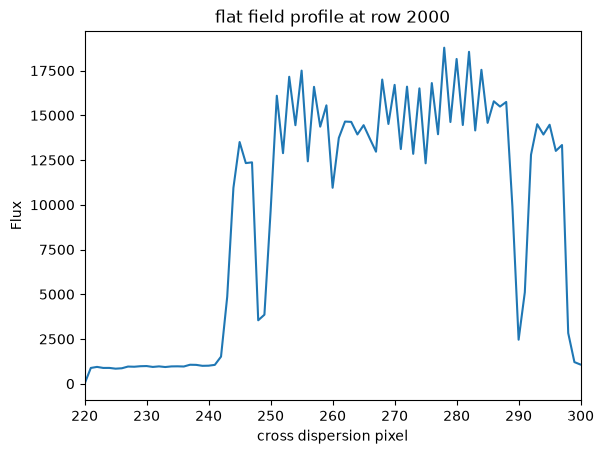

In [9]:
#looking at what we are trying to find

test_row = 2000

plt.plot(flat_data[test_row, :])
plt.xlim(220,300)
plt.xlabel('cross dispersion pixel')
plt.ylabel('Flux')
plt.title("flat field profile at row 2000")
plt.show()

Smooth out field first to remove minor bumps

In [10]:
from scipy.signal import find_peaks

In [24]:
row = flat_data[2000, :]

search_region = slice(220, 300)
row_segment = row[search_region]

#finding dips
inverted = -row_segment
peaks,properties = find_peaks(inverted, prominence=8000)

#converting back to pixel coordinates
dip_positions = peaks + 220

print("Detected dip positions:", dip_positions)
print("Prominences:", properties['prominences'])

Detected dip positions: [248 290]
Prominences: [ 9964. 12044.]


This proves that this smoothing method works so now we can loop it over every row

In [58]:
n_rows = flat_data.shape[0]
tramline1 = np.full(n_rows, np.nan)
tramline2 = np.full(n_rows, np.nan)

min_signal_threshold = 1000 #this allows us to skip rows with no illumination 
for i in range(n_rows):
    row_segment = flat_data[i,:]
    if row_segment.max() < min_signal_threshold:
        continue
        
    inverted = -row_segment
    relative_prominence = 0.1*row_segment.max()
    peaks,properties = find_peaks(inverted, prominence=relative_prominence)
    dip_positions = peaks
    
    if len(peaks) >= 2:
        top2_idx = np.argsort(properties['prominences'])[-2:]
        top2_peaks = np.sort(peaks[top2_idx]) 
        tramline1[i] = top2_peaks[0] 
        tramline2[i] = top2_peaks[1] 

Now plotting the detected tramlines

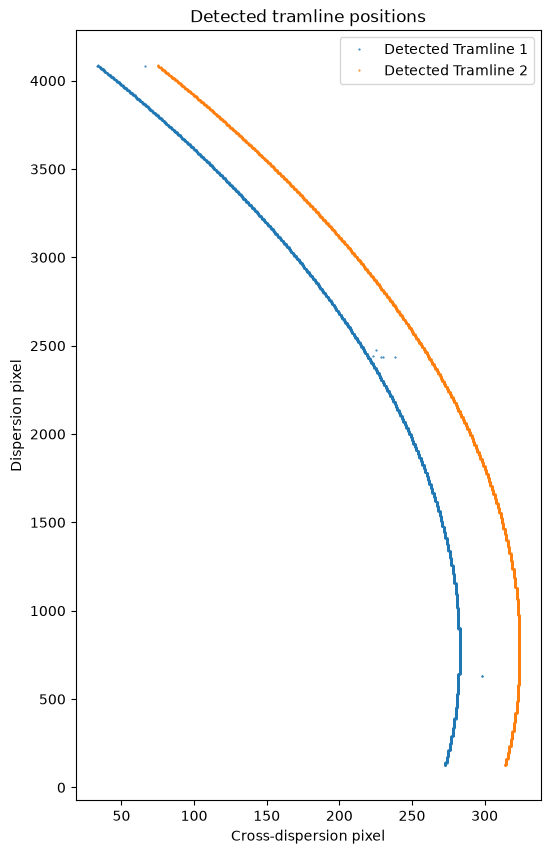

In [70]:
rows = np.arange(n_rows)

plt.figure(figsize=(6, 10))
plt.plot(tramline1, rows, '.', markersize=1, label='Detected Tramline 1')
plt.plot(tramline2, rows, '.', markersize=1, label='Detected Tramline 2')
plt.xlabel('Cross-dispersion pixel')
plt.ylabel('Dispersion pixel')
plt.title('Detected tramline positions')
plt.legend()
plt.savefig('figures/task4_detectedtramlinepositions,png', dpi=150)
plt.show()

In [60]:
valid1 = ~np.isnan(tramline1)
valid2 = ~np.isnan(tramline2)

coeffs1 = np.polyfit(rows[valid1], tramline1[valid1], 3)
coeffs2 = np.polyfit(rows[valid2], tramline2[valid2], 3)

fit_rows = np.arange(rows[valid1].min(), rows[valid1].max()+1)
fit1 = np.polyval(coeffs1, fit_rows)
fit2 = np.polyval(coeffs2, fit_rows)

Valid1/2 - masks any issues where nothing is detected so only real rows are used for fitting.
Coeffs1/2 - describing each tramline's position as a function of dispersion row -> polyfit finding best cubic coefficients
Fit rows - defines complete continuous range of rows
fit1/2 -smooths tramline curve

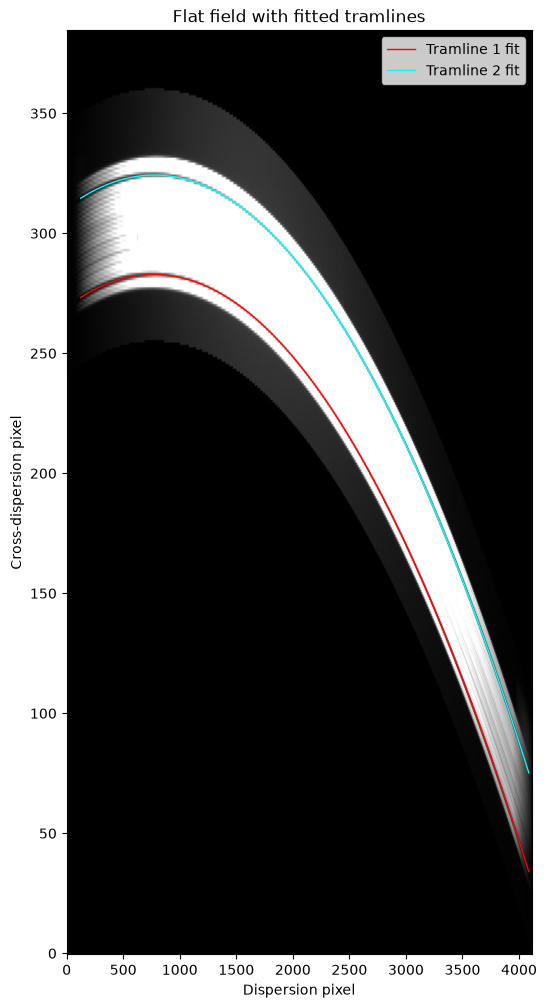

In [71]:
plt.figure(figsize=(6, 12))
plt.imshow(flat_data.T, origin='lower', aspect='auto', cmap='gray', vmin=0, vmax=5000)
plt.plot(fit_rows, fit1, color='red', linewidth=1, label='Tramline 1 fit')
plt.plot(fit_rows, fit2, color='cyan', linewidth=1, label='Tramline 2 fit')
plt.xlabel('Dispersion pixel')
plt.ylabel('Cross-dispersion pixel')
plt.title('Flat field with fitted tramlines')
plt.legend()
plt.savefig('figures/task4_tramlines.png', dpi=150)
plt.show()

Plot overlayed with actual data

Explanation of Approach -

To locate the low illumination dips with the fibre bundle, each row of the flat field was searched independently using the scipy find peaks package. This was applied to the inverted profile so that dips were detectable "peaks".
A relative prominence threshold was used (10% of each rows peak brightness) so that detection scaled natrually with each illumination leve. Initially it was planned to do one prominence threshold however a large fraction of rows failes due to fainter tramlines or the threshold being too strict towards the edges.
THe other issue was that some rows had more thna 2 peaks, so to fix this only the two dips with the highest prominence were maintained, this made the method more robust across a full range of brightness.
Once all rows had been successfully handles a cubic polynomial was fit to each tramlines position as a function of dispersion row. A low order polynomial was chosen as the tramlines showed a single gentre curve across the detector.





Part 2


In [66]:
flat_spectrum = np.full(len(fit_rows), np.nan)
moon_spectrum = np.full(len(fit_rows), np.nan)

for idx, row in enumerate(fit_rows):
    lower = int(np.round(fit1[idx]))
    upper = int(np.round(fit2[idx]))

    flat_spectrum[idx] = flat_data[row, lower:upper].sum()
    moon_spectrum[idx] = moon_data[row, lower:upper].sum()



Looping through every row with a tramline fit, and then rouns the position to the nearest integer pixel and summing them.

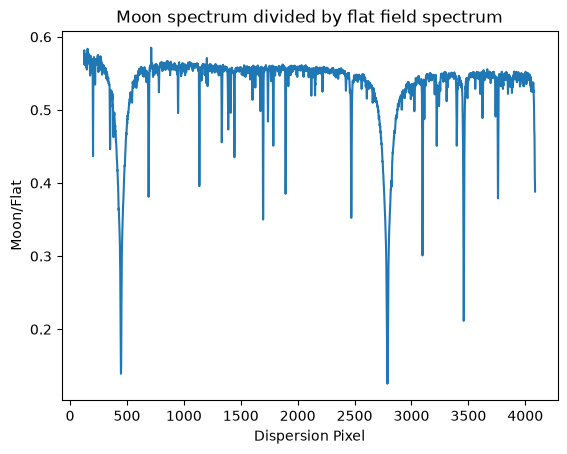

In [73]:
moon_div_flat = moon_spectrum/flat_spectrum

plt.plot(fit_rows, moon_div_flat)
plt.xlabel('Dispersion Pixel')
plt.ylabel('Moon/Flat')
plt.title('Moon spectrum divided by flat field spectrum')
plt.savefig('figures/task4_moonspec_flatfield.png', dpi=150)
plt.show()

Ca II lines at 8498, 8542, and 8662 ˚A.

In [80]:
#finding local minima

inverted_spectrum = -moon_div_flat
peaks, properties = find_peaks(inverted_spectrum, prominence=0.1)

#printing line positions (sorted by strength)
sorted_idx = np.argsort(properties['prominences'])[::-1]
for idx in sorted_idx[:10]:
    pixel= fit_rows[peaks[idx]]
    prominence = properties['prominences'][idx]
    print(f"Pixel: {pixel}, Depth (prominence): {prominence}")

Pixel: 448, Depth (prominence): 0.4445535837802098
Pixel: 2789, Depth (prominence): 0.4302411045788882
Pixel: 3459, Depth (prominence): 0.34031657769482193
Pixel: 3097, Depth (prominence): 0.2456850710628214
Pixel: 1696, Depth (prominence): 0.21214531932185127
Pixel: 2471, Depth (prominence): 0.19657761264538032
Pixel: 690, Depth (prominence): 0.17775029177003965
Pixel: 1894, Depth (prominence): 0.1760493578919144
Pixel: 1136, Depth (prominence): 0.1753559507084113
Pixel: 3760, Depth (prominence): 0.1735563903529933


Looking at this list of pixels and its depth, our top three pixels have a much higher prominence than the rest of them. This strongly suggests that pixel 448, 2789, and 3459 correlate the the Ca II lines. Since the dispersion pixel scales linearly with wavelength we can assume which pixels correlate to which Ca II lines as such:

8498 --> pixel 448
8542 --> pixel 2789
8662 --> pixel 8662

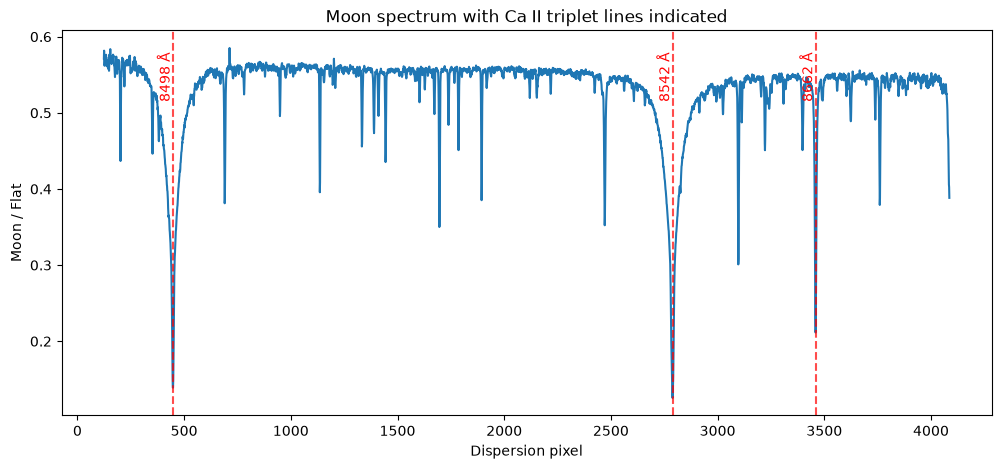

In [81]:
#plotting over graph

ca_ii_lines = {
    8498: 448,
    8542: 2789,
    8662: 3459
}

plt.figure(figsize=(12,5))
plt.plot(fit_rows, moon_div_flat)
for wavelength, pixel in ca_ii_lines.items():
    plt.axvline(pixel, color='red', linestyle='--', alpha=0.7)
    plt.text(pixel, 0.58, f'{wavelength} Å', rotation=90, color='red', va='top', ha='right')

plt.xlabel('Dispersion pixel')
plt.ylabel('Moon / Flat')
plt.title('Moon spectrum with Ca II triplet lines indicated')
plt.savefig('figures/task4_spectrum_caII.png', dpi=150)
plt.show()